In [90]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor

df = pd.read_csv('Agriculture_price_dataset.csv')
print("All libraries imported successfully!")

All libraries imported successfully!


In [91]:
print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (737392, 10)


In [92]:
print("Column Names:")
print(df.columns.tolist())
df.head()
df.info()
print("Missing Values:")
print(df.isnull().sum())

print("\nMissing Percentage:")
print((df.isnull().mean() * 100).round(2))
print("Duplicate rows:", df.duplicated().sum())
print("Number of unique commodities:", df["Commodity"].nunique())

print("\nTop commodities:")
print(df["Commodity"].value_counts().head(20))

Column Names:
['STATE', 'District Name', 'Market Name', 'Commodity', 'Variety', 'Grade', 'Min_Price', 'Max_Price', 'Modal_Price', 'Price Date']
<class 'pandas.DataFrame'>
RangeIndex: 737392 entries, 0 to 737391
Data columns (total 10 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   STATE          737392 non-null  str    
 1   District Name  737392 non-null  str    
 2   Market Name    737392 non-null  str    
 3   Commodity      737392 non-null  str    
 4   Variety        737392 non-null  str    
 5   Grade          737392 non-null  str    
 6   Min_Price      737392 non-null  float64
 7   Max_Price      737392 non-null  float64
 8   Modal_Price    737392 non-null  float64
 9   Price Date     737392 non-null  str    
dtypes: float64(3), str(7)
memory usage: 93.0 MB
Missing Values:
STATE            0
District Name    0
Market Name      0
Commodity        0
Variety          0
Grade            0
Min_Price        0
Max_Price        0

In [93]:
# Dataset overview
print("Rows:", len(df))
print("Columns:", len(df.columns))

print("\nUnique values per column:")
print(df.nunique().sort_values())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nPrice statistics:")
print(df[["Min_Price", "Max_Price", "Modal_Price"]].describe())

print("\nDate information:")
print("Unique dates:", df["Price Date"].nunique())
print("First dates:")
print(df["Price Date"].head())

Rows: 737392
Columns: 10

Unique values per column:
Commodity           5
Grade               7
STATE              30
Variety            94
District Name     373
Price Date        737
Market Name      1598
Min_Price        4124
Modal_Price      5156
Max_Price        5342
dtype: int64

Duplicate rows: 0

Price statistics:
           Min_Price      Max_Price    Modal_Price
count  737392.000000  737392.000000  737392.000000
mean     2204.849862    2659.733824    2474.484638
std      1920.977696    2145.250773    2023.851909
min         0.000000       0.000000       0.000000
25%      1100.000000    1500.000000    1300.000000
50%      2000.000000    2300.000000    2150.000000
75%      2700.000000    3205.000000    3000.000000
max    420000.000000  480000.000000  460000.000000

Date information:
Unique dates: 737
First dates:
0    6/6/2023
1    6/6/2023
2    6/6/2023
3    6/6/2023
4    6/6/2023
Name: Price Date, dtype: str


In [94]:
# Convert date temporarily for inspection
date_test = pd.to_datetime(df["Price Date"], errors="coerce")

print("Invalid dates:", date_test.isna().sum())
print("Minimum date:", date_test.min())
print("Maximum date:", date_test.max())

Invalid dates: 0
Minimum date: 2023-06-06 00:00:00
Maximum date: 2025-06-11 00:00:00


In [95]:
target_commodities = ["Onion", "Potato", "Tomato"]

target_df = df[df["Commodity"].isin(target_commodities)]

print("Rows for target commodities:", len(target_df))

print("\nCommodity distribution:")
print(target_df["Commodity"].value_counts())

print("\nDate range:")
target_dates = pd.to_datetime(target_df["Price Date"], errors="coerce")
print("Start:", target_dates.min())
print("End:", target_dates.max())

print("\nUnique dates per commodity:")
print(
    target_df.groupby("Commodity")["Price Date"]
    .nunique()
)

Rows for target commodities: 652634

Commodity distribution:
Commodity
Potato    327332
Onion     298658
Tomato     26644
Name: count, dtype: int64

Date range:
Start: 2023-06-06 00:00:00
End: 2025-06-11 00:00:00

Unique dates per commodity:
Commodity
Onion     647
Potato    737
Tomato    154
Name: Price Date, dtype: int64


In [96]:
bad_price_rows = df[
    (df["Min_Price"] < 0) |
    (df["Max_Price"] < 0) |
    (df["Modal_Price"] < 0) |
    (df["Min_Price"] > df["Max_Price"]) |
    (df["Modal_Price"] < df["Min_Price"]) |
    (df["Modal_Price"] > df["Max_Price"])
]

print("Invalid price rows:", len(bad_price_rows))

bad_price_rows.head(20)

Invalid price rows: 1860


,STATE,District Name,Market Name,Commodity,Variety,Grade,Min_Price,Max_Price,Modal_Price,Price Date
208,Madhya Pradesh,gwalior,Lashkar,Wheat,Mill Quality,FAQ,2245.0,0.0,2255.0,6/6/2023
961,Uttar Pradesh,sonbhadra,Dudhi,Onion,Onion,FAQ,800.0,0.0,900.0,6/6/2023
1414,Uttar Pradesh,sonbhadra,Dudhi,Potato,Other,FAQ,900.0,0.0,1000.0,6/6/2023
1821,Uttar Pradesh,sonbhadra,Dudhi,Tomato,Deshi,FAQ,900.0,0.0,1000.0,6/6/2023
1913,Uttar Pradesh,sonbhadra,Dudhi,Tomato,Deshi,FAQ,1000.0,0.0,1100.0,6/7/2023
3068,Uttar Pradesh,sonbhadra,Dudhi,Onion,Onion,FAQ,700.0,0.0,800.0,6/7/2023
3825,Uttar Pradesh,sonbhadra,Dudhi,Onion,Onion,FAQ,900.0,0.0,1000.0,6/8/2023
3861,Uttar Pradesh,sonbhadra,Dudhi,Potato,Other,FAQ,900.0,0.0,1000.0,6/8/2023
5093,Uttar Pradesh,sonbhadra,Dudhi,Tomato,Deshi,FAQ,900.0,0.0,1000.0,6/8/2023
5618,Uttar Pradesh,sonbhadra,Dudhi,Tomato,Deshi,FAQ,1000.0,0.0,1100.0,6/9/2023


In [97]:
print("Zero Min Price:", (df["Min_Price"] == 0).sum())
print("Zero Max Price:", (df["Max_Price"] == 0).sum())
print("Zero Modal Price:", (df["Modal_Price"] == 0).sum())

Zero Min Price: 114
Zero Max Price: 611
Zero Modal Price: 3


In [98]:
# Create a working copy
data = df.copy()

print("Original shape:", data.shape)

Original shape: (737392, 10)


In [99]:
data["Price Date"] = pd.to_datetime(
    data["Price Date"],
    errors="coerce"
)

print("Invalid dates:", data["Price Date"].isna().sum())

Invalid dates: 0


In [100]:
target_commodities = ["Onion", "Potato", "Tomato"]

data = data[
    data["Commodity"].isin(target_commodities)
].copy()

print("After commodity filtering:", data.shape)

print("\nCommodity counts:")
print(data["Commodity"].value_counts())

After commodity filtering: (652634, 10)

Commodity counts:
Commodity
Potato    327332
Onion     298658
Tomato     26644
Name: count, dtype: int64


In [101]:
invalid_price_mask = (
    (data["Min_Price"] <= 0) |
    (data["Max_Price"] <= 0) |
    (data["Modal_Price"] <= 0) |
    (data["Min_Price"] > data["Max_Price"]) |
    (data["Modal_Price"] < data["Min_Price"]) |
    (data["Modal_Price"] > data["Max_Price"])
)

print("Invalid price rows:", invalid_price_mask.sum())
print("Valid price rows:", (~invalid_price_mask).sum())

Invalid price rows: 1239
Valid price rows: 651395


In [102]:
print(
    data.loc[invalid_price_mask, "Commodity"]
    .value_counts()
)
print(
    data.loc[invalid_price_mask, ["Commodity", "Min_Price",
                                  "Max_Price", "Modal_Price"]]
    .head(20)
)

Commodity
Onion     764
Potato    404
Tomato     71
Name: count, dtype: int64
      Commodity  Min_Price  Max_Price  Modal_Price
961       Onion      800.0        0.0        900.0
1414     Potato      900.0        0.0       1000.0
1821     Tomato      900.0        0.0       1000.0
1913     Tomato     1000.0        0.0       1100.0
3068      Onion      700.0        0.0        800.0
3825      Onion      900.0        0.0       1000.0
3861     Potato      900.0        0.0       1000.0
5093     Tomato      900.0        0.0       1000.0
5618     Tomato     1000.0        0.0       1100.0
6166     Potato     1000.0        0.0       1100.0
7028      Onion      700.0        0.0        800.0
7622     Tomato      900.0        0.0       1000.0
7823      Onion      800.0        0.0        900.0
9185     Potato     1000.0        0.0       1100.0
9372     Tomato     1000.0        0.0       1100.0
9620      Onion      700.0        0.0        800.0
10388    Tomato      900.0        0.0       1000.0
1139

In [103]:
data = data[~invalid_price_mask].copy()

print("Clean dataset shape:", data.shape)

Clean dataset shape: (651395, 10)


In [104]:
print("Duplicate rows:", data.duplicated().sum())
print(data[["Min_Price", "Max_Price", "Modal_Price"]].describe())
key_cols = [
    "STATE",
    "District Name",
    "Market Name",
    "Commodity",
    "Variety",
    "Grade",
    "Price Date"
]

duplicate_keys = data.duplicated(
    subset=key_cols,
    keep=False
)

print("Repeated market observations:", duplicate_keys.sum())

Duplicate rows: 0
           Min_Price      Max_Price    Modal_Price
count  651395.000000  651395.000000  651395.000000
mean     2179.947793    2663.124966    2468.778025
std      2034.530774    2268.522830    2144.708591
min         2.000000       8.000000       8.000000
25%      1000.000000    1400.000000    1240.000000
50%      1729.000000    2140.000000    2000.000000
75%      2800.000000    3500.000000    3100.000000
max    420000.000000  480000.000000  460000.000000
Repeated market observations: 0


In [105]:
for commodity in ["Onion", "Potato", "Tomato"]:
    print("\n" + "=" * 60)
    print(commodity)
    print("=" * 60)

    temp = data[data["Commodity"] == commodity]

    print(temp[[
        "Min_Price",
        "Max_Price",
        "Modal_Price"
    ]].describe())


Onion
           Min_Price      Max_Price    Modal_Price
count  297894.000000  297894.000000  297894.000000
mean     2427.135229    3018.929757    2784.576450
std      2261.678904    2494.432109    2331.802451
min         2.000000       8.000000       8.000000
25%      1300.000000    1800.000000    1600.000000
50%      2000.000000    2560.000000    2400.000000
75%      3260.000000    4000.000000    3600.000000
max    420000.000000  480000.000000  460000.000000

Potato
           Min_Price      Max_Price    Modal_Price
count  326928.000000  326928.000000  326928.000000
mean     1814.410965    2157.758253    2022.582708
std      1483.187210    1609.213932    1600.500472
min        10.000000      11.000000      11.000000
25%       970.000000    1200.000000    1065.000000
50%      1400.000000    1729.000000    1550.000000
75%      2280.000000    2600.000000    2435.000000
max     56000.000000   60000.000000   58009.000000

Tomato
           Min_Price      Max_Price    Modal_Price
count   

In [106]:
for commodity in ["Onion", "Potato", "Tomato"]:
    print("\n" + "=" * 60)
    print(commodity, "- Highest Modal Prices")
    print("=" * 60)

    temp = data[data["Commodity"] == commodity]

    print(
        temp.nlargest(10, "Modal_Price")[
            [
                "STATE",
                "District Name",
                "Market Name",
                "Commodity",
                "Variety",
                "Grade",
                "Min_Price",
                "Max_Price",
                "Modal_Price",
                "Price Date"
            ]
        ].to_string(index=False)
    )


Onion - Highest Modal Prices
 STATE      District Name         Market Name Commodity Variety Grade  Min_Price  Max_Price  Modal_Price Price Date
 Bihar          jehanabad           Jehanabad     Onion   White   FAQ   420000.0   480000.0     460000.0 2023-11-09
 Bihar          jehanabad           Jehanabad     Onion   White   FAQ   350000.0   400000.0     350000.0 2023-12-19
 Bihar          jehanabad           Jehanabad     Onion   White   FAQ   280000.0   300000.0     300000.0 2025-02-18
 Bihar          jehanabad           Jehanabad     Onion   White   FAQ   250000.0   300000.0     300000.0 2025-02-21
 Bihar          jehanabad           Jehanabad     Onion   White   FAQ   240000.0   240000.0     240000.0 2024-02-23
 Bihar              patna Patna (Musallahpur)     Onion  Medium   FAQ    60000.0    68000.0      64000.0 2023-12-27
 Bihar              patna Patna (Musallahpur)     Onion  Medium   FAQ    60000.0    64000.0      62000.0 2024-01-03
 Bihar              patna Patna (Musallahp

In [107]:
commodity_thresholds = (
    data.groupby("Commodity")["Modal_Price"]
    .quantile(0.995)
    .rename("Upper_99_5")
)

print(commodity_thresholds)

Commodity
Onion      8453.5
Potato     7000.0
Tomato    14200.0
Name: Upper_99_5, dtype: float64


In [108]:
for commodity in ["Onion", "Potato", "Tomato"]:
    threshold = commodity_thresholds[commodity]

    count = (
        (data["Commodity"] == commodity) &
        (data["Modal_Price"] > threshold)
    ).sum()

    print(
        f"{commodity}: "
        f"Threshold = ₹{threshold:,.2f}, "
        f"Outliers = {count}"
    )

Onion: Threshold = ₹8,453.50, Outliers = 1490
Potato: Threshold = ₹7,000.00, Outliers = 1469
Tomato: Threshold = ₹14,200.00, Outliers = 131


In [109]:
for commodity in ["Onion", "Potato", "Tomato"]:
    threshold = commodity_thresholds[commodity]

    print("\n" + "=" * 70)
    print(f"{commodity} - Extreme records")
    print("=" * 70)

    temp = data[
        (data["Commodity"] == commodity) &
        (data["Modal_Price"] > threshold)
    ]

    print(
        temp[
            [
                "STATE",
                "District Name",
                "Market Name",
                "Variety",
                "Grade",
                "Min_Price",
                "Max_Price",
                "Modal_Price",
                "Price Date"
            ]
        ]
        .sort_values("Modal_Price", ascending=False)
        .head(20)
        .to_string(index=False)
    )


Onion - Extreme records
    STATE      District Name                         Market Name Variety Grade  Min_Price  Max_Price  Modal_Price Price Date
    Bihar          jehanabad                           Jehanabad   White   FAQ   420000.0   480000.0     460000.0 2023-11-09
    Bihar          jehanabad                           Jehanabad   White   FAQ   350000.0   400000.0     350000.0 2023-12-19
    Bihar          jehanabad                           Jehanabad   White   FAQ   250000.0   300000.0     300000.0 2025-02-21
    Bihar          jehanabad                           Jehanabad   White   FAQ   280000.0   300000.0     300000.0 2025-02-18
    Bihar          jehanabad                           Jehanabad   White   FAQ   240000.0   240000.0     240000.0 2024-02-23
    Bihar              patna                 Patna (Musallahpur)  Medium   FAQ    60000.0    68000.0      64000.0 2023-12-27
    Bihar              patna                 Patna (Musallahpur)  Medium   FAQ    60000.0    64000.0

In [110]:
# Commodity-specific 99.5% outlier thresholds
upper_limits = (
    data.groupby("Commodity")["Modal_Price"]
    .quantile(0.995)
)

print("99.5% Outlier Thresholds:")
print(upper_limits)

# Map each commodity to its threshold
data["Upper_Limit"] = data["Commodity"].map(upper_limits)

# Remove extreme Modal Price observations
data = data[
    data["Modal_Price"] <= data["Upper_Limit"]
].copy()

# Remove temporary column
data.drop(columns=["Upper_Limit"], inplace=True)

print("\nDataset after outlier removal:")
print("Rows:", len(data))
print("Columns:", len(data.columns))

print("\nCommodity counts:")
print(data["Commodity"].value_counts())

99.5% Outlier Thresholds:
Commodity
Onion      8453.5
Potato     7000.0
Tomato    14200.0
Name: Modal_Price, dtype: float64

Dataset after outlier removal:
Rows: 648305
Columns: 10

Commodity counts:
Commodity
Potato    325459
Onion     296404
Tomato     26442
Name: count, dtype: int64


In [111]:
# Sort the data chronologically within each market/commodity series
data = data.sort_values(
    [
        "STATE",
        "District Name",
        "Market Name",
        "Commodity",
        "Variety",
        "Grade",
        "Price Date"
    ]
).reset_index(drop=True)

print("Data sorted successfully!")
print(data[[
    "STATE",
    "Market Name",
    "Commodity",
    "Price Date",
    "Modal_Price"
]].head(10))

Data sorted successfully!
     STATE Market Name Commodity Price Date  Modal_Price
0   Punjab      Abohar     Onion 2023-06-06       1245.0
1   Punjab      Abohar     Onion 2023-06-07       1024.0
2   Punjab      Abohar     Onion 2023-06-08       1005.0
3   Punjab      Abohar     Onion 2023-06-12       1025.0
4   Punjab      Abohar     Onion 2023-06-13       1025.0
5   Punjab      Abohar     Onion 2023-06-14       1025.0
6   Punjab      Abohar     Onion 2023-06-15       1025.0
7   Punjab      Abohar     Onion 2023-06-16       1025.0
8   Punjab      Abohar     Onion 2023-06-17       1112.0
9   Punjab      Abohar     Onion 2023-06-19       1200.0


In [112]:
series_columns = [
    "STATE",
    "District Name",
    "Market Name",
    "Commodity",
    "Variety",
    "Grade"
]

series_counts = (
    data.groupby(series_columns)
    .size()
    .sort_values(ascending=False)
)

print("Number of individual price series:", len(series_counts))

print("\nLargest series:")
print(series_counts.head(10))

Number of individual price series: 4179

Largest series:
STATE          District Name      Market Name  Commodity  Variety  Grade
Uttar Pradesh  prayagraj          Ajuha        Potato     Desi     FAQ      728
               sambhal            Sambhal      Potato     Desi     FAQ      728
               balrampur          Tulsipur     Potato     Desi     FAQ      728
               shahjahanpur       Puwaha       Potato     Desi     FAQ      727
West Bengal    paschim bardhaman  Asansol      Potato     Jyoti    FAQ      720
                                  Durgapur     Potato     Jyoti    FAQ      719
Uttar Pradesh  gonda              Nawabganj    Potato     Desi     FAQ      712
West Bengal    north 24 parganas  Barasat      Potato     Other    FAQ      709
Uttar Pradesh  hardoi             Madhoganj    Potato     Badshah  FAQ      707
                                  Sandila      Potato     Badshah  FAQ      706
dtype: int64


In [113]:
group_columns = [
    "STATE",
    "District Name",
    "Market Name",
    "Commodity",
    "Variety",
    "Grade"
]

data["Lag_1"] = (
    data.groupby(group_columns)["Modal_Price"]
    .shift(1)
)

data["Lag_3"] = (
    data.groupby(group_columns)["Modal_Price"]
    .shift(3)
)

data["Lag_7"] = (
    data.groupby(group_columns)["Modal_Price"]
    .shift(7)
)

data["Lag_14"] = (
    data.groupby(group_columns)["Modal_Price"]
    .shift(14)
)

data["Lag_30"] = (
    data.groupby(group_columns)["Modal_Price"]
    .shift(30)
)

In [114]:
data["Rolling_Mean_7"] = (
    data.groupby(group_columns)["Modal_Price"]
    .transform(lambda x: x.shift(1).rolling(7).mean())
)

data["Rolling_Mean_14"] = (
    data.groupby(group_columns)["Modal_Price"]
    .transform(lambda x: x.shift(1).rolling(14).mean())
)

data["Rolling_Mean_30"] = (
    data.groupby(group_columns)["Modal_Price"]
    .transform(lambda x: x.shift(1).rolling(30).mean())
)

In [115]:
data["Previous_Price_Change"] = (
    data["Lag_1"] - data["Lag_3"]
)

data["Previous_Price_Change_Percent"] = (
    (data["Lag_1"] - data["Lag_3"])
    / data["Lag_3"]
) * 100

In [116]:
data["Year"] = data["Price Date"].dt.year
data["Month"] = data["Price Date"].dt.month
data["Day"] = data["Price Date"].dt.day
data["DayOfWeek"] = data["Price Date"].dt.dayofweek
data["WeekOfYear"] = data["Price Date"].dt.isocalendar().week.astype(int)

In [117]:
data["Target_Next_Price"] = (
    data.groupby(group_columns)["Modal_Price"]
    .shift(-1)
)

In [118]:
feature_columns = [
    "Lag_1",
    "Lag_3",
    "Lag_7",
    "Lag_14",
    "Lag_30",
    "Rolling_Mean_7",
    "Rolling_Mean_14",
    "Rolling_Mean_30",
    "Previous_Price_Change",
    "Previous_Price_Change_Percent"
]

print("Missing values in lag/rolling features:")

print(
    data[feature_columns].isnull().sum()
)

Missing values in lag/rolling features:
Lag_1                             4179
Lag_3                            11616
Lag_7                            25280
Lag_14                           47332
Lag_30                           92496
Rolling_Mean_7                   25280
Rolling_Mean_14                  47332
Rolling_Mean_30                  92496
Previous_Price_Change            11616
Previous_Price_Change_Percent    11616
dtype: int64


In [119]:
print("Missing Target_Next_Price:")
print(data["Target_Next_Price"].isnull().sum())

print("\nCurrent dataset shape:")
print(data.shape)

Missing Target_Next_Price:
4179

Current dataset shape:
(648305, 26)


In [120]:
group_columns = [
    "STATE",
    "District Name",
    "Market Name",
    "Commodity",
    "Variety",
    "Grade"
]

series_lengths = (
    data.groupby(group_columns)
    .size()
)

print("Number of individual series:", len(series_lengths))

print("\nSeries length statistics:")
print(series_lengths.describe())

print("\nSeries with fewer than 31 observations:")
print((series_lengths < 31).sum())

Number of individual series: 4179

Series length statistics:
count    4179.000000
mean      155.134003
std       191.901775
min         1.000000
25%        11.000000
50%        55.000000
75%       264.000000
max       728.000000
dtype: float64

Series with fewer than 31 observations:
1590


In [121]:
clean_data = data.copy()

print("Clean dataset saved in memory:", clean_data.shape)

Clean dataset saved in memory: (648305, 26)


In [122]:
old_feature_columns = [
    "Lag_1",
    "Lag_3",
    "Lag_7",
    "Lag_14",
    "Lag_30",
    "Rolling_Mean_7",
    "Rolling_Mean_14",
    "Rolling_Mean_30",
    "Previous_Price_Change",
    "Previous_Price_Change_Percent",
    "Target_Next_Price"
]

data = clean_data.drop(
    columns=old_feature_columns,
    errors="ignore"
).copy()

print("Shape after removing old features:", data.shape)

Shape after removing old features: (648305, 15)


In [123]:
market_day_cols = [
    "STATE",
    "District Name",
    "Market Name",
    "Commodity",
    "Price Date"
]

duplicates = data.duplicated(
    subset=market_day_cols,
    keep=False
)

print("Records involved in multiple market-day observations:",
      duplicates.sum())

Records involved in multiple market-day observations: 54001


In [124]:
print(
    data.loc[
        duplicates,
        market_day_cols + [
            "Variety",
            "Grade",
            "Modal_Price"
        ]
    ].head(20).to_string(index=False)
)

         STATE District Name     Market Name Commodity Price Date  Variety Grade  Modal_Price
Andhra Pradesh     hyderabad Mahboob Manison     Onion 2023-06-06 1st Sort   FAQ       1700.0
Andhra Pradesh     hyderabad Mahboob Manison     Onion 2023-06-09 1st Sort   FAQ       1500.0
Andhra Pradesh     hyderabad Mahboob Manison     Onion 2023-06-10 1st Sort   FAQ       1600.0
Andhra Pradesh     hyderabad Mahboob Manison     Onion 2023-06-12 1st Sort   FAQ       1600.0
Andhra Pradesh     hyderabad Mahboob Manison     Onion 2023-06-13 1st Sort   FAQ       1500.0
Andhra Pradesh     hyderabad Mahboob Manison     Onion 2023-06-14 1st Sort   FAQ       1400.0
Andhra Pradesh     hyderabad Mahboob Manison     Onion 2023-06-15 1st Sort   FAQ       1600.0
Andhra Pradesh     hyderabad Mahboob Manison     Onion 2023-06-16 1st Sort   FAQ       1500.0
Andhra Pradesh     hyderabad Mahboob Manison     Onion 2023-06-17 1st Sort   FAQ       1400.0
Andhra Pradesh     hyderabad Mahboob Manison     Onion 2023-

In [125]:
market_daily = (
    data.groupby(market_day_cols, as_index=False)
    .agg(
        Modal_Price=("Modal_Price", "median"),
        Min_Price=("Min_Price", "median"),
        Max_Price=("Max_Price", "median")
    )
)

In [126]:
print("Market-level daily dataset:")
print("Rows:", len(market_daily))
print("Columns:", len(market_daily.columns))

print("\nCommodity counts:")
print(market_daily["Commodity"].value_counts())

Market-level daily dataset:
Rows: 620070
Columns: 8

Commodity counts:
Commodity
Potato    315523
Onion     278227
Tomato     26320
Name: count, dtype: int64


In [127]:
print(market_daily.head())

print("\nData types:")
print(market_daily.dtypes)

print("\nMissing values:")
print(market_daily.isnull().sum())

print("\nDuplicate market-day rows:")
print(
    market_daily.duplicated(
        subset=[
            "STATE",
            "District Name",
            "Market Name",
            "Commodity",
            "Price Date"
        ]
    ).sum()
)

     STATE District Name Market Name Commodity Price Date  Modal_Price  \
0   Punjab       fazilka      Abohar     Onion 2023-06-06       1245.0   
1   Punjab       fazilka      Abohar     Onion 2023-06-07       1024.0   
2   Punjab       fazilka      Abohar     Onion 2023-06-08       1005.0   
3   Punjab       fazilka      Abohar     Onion 2023-06-12       1025.0   
4   Punjab       fazilka      Abohar     Onion 2023-06-13       1025.0   

   Min_Price  Max_Price  
0      840.0     1345.0  
1      845.0     1540.0  
2      845.0     1325.0  
3      980.0     1500.0  
4      850.0     1250.0  

Data types:
STATE                       str
District Name               str
Market Name                 str
Commodity                   str
Price Date       datetime64[us]
Modal_Price             float64
Min_Price               float64
Max_Price               float64
dtype: object

Missing values:
STATE            0
District Name    0
Market Name      0
Commodity        0
Price Date       0
Moda

In [128]:
market_daily = market_daily.sort_values(
    [
        "STATE",
        "District Name",
        "Market Name",
        "Commodity",
        "Price Date"
    ]
).reset_index(drop=True)

print("Market-level data sorted successfully!")

Market-level data sorted successfully!


In [129]:
market_group = [
    "STATE",
    "District Name",
    "Market Name",
    "Commodity"
]

market_series_lengths = (
    market_daily
    .groupby(market_group)
    .size()
)

print("Number of market-commodity series:",
      len(market_series_lengths))

print("\nSeries statistics:")
print(market_series_lengths.describe())

print("\nSeries with at least 31 observations:",
      (market_series_lengths >= 31).sum())

print("Series with fewer than 31 observations:",
      (market_series_lengths < 31).sum())

Number of market-commodity series: 2687

Series statistics:
count    2687.000000
mean      230.766654
std       219.062084
min         1.000000
25%        33.000000
50%       149.000000
75%       424.000000
max       735.000000
dtype: float64

Series with at least 31 observations: 2042
Series with fewer than 31 observations: 645


In [130]:
# Keep only market-commodity series with at least 31 observations

series_counts = (
    market_daily
    .groupby(market_group)
    .size()
)

valid_series = series_counts[series_counts >= 31].index

market_daily = (
    market_daily
    .set_index(market_group)
    .loc[valid_series]
    .reset_index()
)

print("After removing short series:")
print("Rows:", len(market_daily))
print("Series:", market_daily.groupby(market_group).ngroups)

print("\nCommodity counts:")
print(market_daily["Commodity"].value_counts())

After removing short series:
Rows: 611718
Series: 2042

Commodity counts:
Commodity
Potato    312828
Onion     276142
Tomato     22748
Name: count, dtype: int64


In [131]:
# Make sure data is sorted
market_daily = market_daily.sort_values(
    market_group + ["Price Date"]
).reset_index(drop=True)

# Create lag features
market_daily["Lag_1"] = (
    market_daily.groupby(market_group)["Modal_Price"].shift(1)
)

market_daily["Lag_3"] = (
    market_daily.groupby(market_group)["Modal_Price"].shift(3)
)

market_daily["Lag_7"] = (
    market_daily.groupby(market_group)["Modal_Price"].shift(7)
)

market_daily["Lag_14"] = (
    market_daily.groupby(market_group)["Modal_Price"].shift(14)
)

market_daily["Lag_30"] = (
    market_daily.groupby(market_group)["Modal_Price"].shift(30)
)

In [132]:
market_daily["Rolling_Mean_7"] = (
    market_daily.groupby(market_group)["Modal_Price"]
    .transform(lambda x: x.shift(1).rolling(7).mean())
)

market_daily["Rolling_Mean_14"] = (
    market_daily.groupby(market_group)["Modal_Price"]
    .transform(lambda x: x.shift(1).rolling(14).mean())
)

market_daily["Rolling_Mean_30"] = (
    market_daily.groupby(market_group)["Modal_Price"]
    .transform(lambda x: x.shift(1).rolling(30).mean())
)

In [133]:
market_daily["Year"] = market_daily["Price Date"].dt.year
market_daily["Month"] = market_daily["Price Date"].dt.month
market_daily["DayOfWeek"] = market_daily["Price Date"].dt.dayofweek
market_daily["DayOfYear"] = market_daily["Price Date"].dt.dayofyear

In [134]:
market_daily["Previous_Price_Change"] = (
    market_daily["Lag_1"] - market_daily["Lag_3"]
)

market_daily["Previous_Price_Change_Percent"] = (
    (market_daily["Lag_1"] - market_daily["Lag_3"])
    / market_daily["Lag_3"]
) * 100

In [135]:
market_daily["Target_Next_Price"] = (
    market_daily
    .groupby(market_group)["Modal_Price"]
    .shift(-1)
)

In [136]:
feature_columns = [
    "Lag_1",
    "Lag_3",
    "Lag_7",
    "Lag_14",
    "Lag_30",
    "Rolling_Mean_7",
    "Rolling_Mean_14",
    "Rolling_Mean_30",
    "Previous_Price_Change",
    "Previous_Price_Change_Percent",
    "Year",
    "Month",
    "DayOfWeek",
    "DayOfYear"
]

print("Feature missing values:")
print(market_daily[feature_columns].isnull().sum())

print("\nTarget missing values:")
print(market_daily["Target_Next_Price"].isnull().sum())

print("\nFinal shape:")
print(market_daily.shape)

Feature missing values:
Lag_1                             2042
Lag_3                             6126
Lag_7                            14294
Lag_14                           28588
Lag_30                           61260
Rolling_Mean_7                   14294
Rolling_Mean_14                  28588
Rolling_Mean_30                  61260
Previous_Price_Change             6126
Previous_Price_Change_Percent     6126
Year                                 0
Month                                0
DayOfWeek                            0
DayOfYear                            0
dtype: int64

Target missing values:
2042

Final shape:
(611718, 23)


In [137]:
# Features used by the model
feature_columns = [
    "Lag_1",
    "Lag_3",
    "Lag_7",
    "Lag_14",
    "Lag_30",
    "Rolling_Mean_7",
    "Rolling_Mean_14",
    "Rolling_Mean_30",
    "Previous_Price_Change",
    "Previous_Price_Change_Percent",
    "Year",
    "Month",
    "DayOfWeek",
    "DayOfYear"
]

target_column = "Target_Next_Price"

# Remove rows where features or target are unavailable
model_data = market_daily.dropna(
    subset=feature_columns + [target_column]
).copy()

print("Final ML dataset shape:", model_data.shape)

Final ML dataset shape: (548416, 23)


In [138]:
print("Missing feature values:")
print(model_data[feature_columns].isnull().sum())

print("\nMissing target values:")
print(model_data[target_column].isnull().sum())

print("\nFinal ML dataset:")
print(model_data.shape)

Missing feature values:
Lag_1                            0
Lag_3                            0
Lag_7                            0
Lag_14                           0
Lag_30                           0
Rolling_Mean_7                   0
Rolling_Mean_14                  0
Rolling_Mean_30                  0
Previous_Price_Change            0
Previous_Price_Change_Percent    0
Year                             0
Month                            0
DayOfWeek                        0
DayOfYear                        0
dtype: int64

Missing target values:
0

Final ML dataset:
(548416, 23)


In [139]:
print("Minimum date:", model_data["Price Date"].min())
print("Maximum date:", model_data["Price Date"].max())

print("\nRecords per year:")
print(
    model_data["Year"].value_counts().sort_index()
)

Minimum date: 2023-07-06 00:00:00
Maximum date: 2025-06-10 00:00:00

Records per year:
Year
2023    132919
2024    274428
2025    141069
Name: count, dtype: int64


In [140]:
train_data = model_data[
    model_data["Price Date"] < "2025-01-01"
].copy()

test_data = model_data[
    model_data["Price Date"] >= "2025-01-01"
].copy()

print("Training data:", train_data.shape)
print("Testing data:", test_data.shape)

print("\nTraining date range:")
print(train_data["Price Date"].min(), "→", train_data["Price Date"].max())

print("\nTesting date range:")
print(test_data["Price Date"].min(), "→", test_data["Price Date"].max())

Training data: (407347, 23)
Testing data: (141069, 23)

Training date range:
2023-07-06 00:00:00 → 2024-12-31 00:00:00

Testing date range:
2025-01-01 00:00:00 → 2025-06-10 00:00:00


In [141]:
feature_columns = [
    "Lag_1",
    "Lag_3",
    "Lag_7",
    "Lag_14",
    "Lag_30",
    "Rolling_Mean_7",
    "Rolling_Mean_14",
    "Rolling_Mean_30",
    "Previous_Price_Change",
    "Previous_Price_Change_Percent",
    "Year",
    "Month",
    "DayOfWeek",
    "DayOfYear"
]

In [142]:
target_column = "Target_Next_Price"

In [143]:
X_train = train_data[feature_columns]
y_train = train_data[target_column]

X_test = test_data[feature_columns]
y_test = test_data[target_column]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (407347, 14)
y_train: (407347,)
X_test: (141069, 14)
y_test: (141069,)


In [144]:
model_xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

In [145]:
print("Training XGBoost...")

model_xgb.fit(
    X_train,
    y_train
)

print("Training completed!")

Training XGBoost...
Training completed!


In [146]:
y_pred = model_xgb.predict(X_test)

print("Predictions generated:", len(y_pred))

print("\nFirst 10 predictions:")
print(y_pred[:10])

Predictions generated: 141069

First 10 predictions:
[4020.5842 3420.8052 3161.0916 3069.7073 3052.2485 2867.0935 2789.0142
 2777.2942 2854.2595 2519.8672]


In [147]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

r2 = r2_score(y_test, y_pred)

print("\nXGBoost Model V1")
print("=" * 40)
print(f"MAE  : ₹{mae:.2f}")
print(f"RMSE : ₹{rmse:.2f}")
print(f"R²   : {r2:.4f}")


XGBoost Model V1
MAE  : ₹162.86
RMSE : ₹284.30
R²   : 0.9481


In [148]:
from sklearn.preprocessing import OneHotEncoder

categorical_columns = [
    "STATE",
    "District Name",
    "Market Name",
    "Commodity"
]

encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=True
)

In [149]:
X_train_cat = encoder.fit_transform(
    train_data[categorical_columns]
)

X_test_cat = encoder.transform(
    test_data[categorical_columns]
)

print("Categorical train shape:", X_train_cat.shape)
print("Categorical test shape:", X_test_cat.shape)

Categorical train shape: (407347, 1238)
Categorical test shape: (141069, 1238)


In [150]:
from scipy.sparse import hstack

X_train_num = train_data[feature_columns].values
X_test_num = test_data[feature_columns].values

X_train_v2 = hstack([
    X_train_num,
    X_train_cat
])

X_test_v2 = hstack([
    X_test_num,
    X_test_cat
])

print("V2 training shape:", X_train_v2.shape)
print("V2 testing shape:", X_test_v2.shape)

V2 training shape: (407347, 1252)
V2 testing shape: (141069, 1252)


In [151]:
model_xgb_v2 = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

In [152]:
print("Training XGBoost V2...")

model_xgb_v2.fit(
    X_train_v2,
    y_train
)

print("V2 training completed!")

Training XGBoost V2...
V2 training completed!


In [153]:
y_pred_v2 = model_xgb_v2.predict(X_test_v2)

mae_v2 = mean_absolute_error(y_test, y_pred_v2)

rmse_v2 = np.sqrt(
    mean_squared_error(y_test, y_pred_v2)
)

r2_v2 = r2_score(y_test, y_pred_v2)

print("\nXGBoost Model V2")
print("=" * 40)
print(f"MAE  : ₹{mae_v2:.2f}")
print(f"RMSE : ₹{rmse_v2:.2f}")
print(f"R²   : {r2_v2:.4f}")


XGBoost Model V2
MAE  : ₹179.07
RMSE : ₹296.74
R²   : 0.9434


In [154]:
print("Test-set commodity distribution:")
print(test_data["Commodity"].value_counts())

print("\nFull model-data commodity distribution:")
print(model_data["Commodity"].value_counts())

print("\nLatest date by commodity in model_data:")
print(
    model_data.groupby("Commodity")["Price Date"].max()
)

Test-set commodity distribution:
Commodity
Potato    78677
Onion     62392
Name: count, dtype: int64

Full model-data commodity distribution:
Commodity
Potato    288307
Onion     250164
Tomato      9945
Name: count, dtype: int64

Latest date by commodity in model_data:
Commodity
Onion    2025-06-10
Potato   2025-06-10
Tomato   2023-11-05
Name: Price Date, dtype: datetime64[us]


In [155]:

importance = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": model_xgb.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

print(importance)

                          Feature  Importance
0                           Lag_1    0.779326
5                  Rolling_Mean_7    0.140704
1                           Lag_3    0.029248
10                           Year    0.009865
13                      DayOfYear    0.008108
6                 Rolling_Mean_14    0.006813
11                          Month    0.004703
9   Previous_Price_Change_Percent    0.003725
4                          Lag_30    0.003519
7                 Rolling_Mean_30    0.003317
8           Previous_Price_Change    0.003243
12                      DayOfWeek    0.002586
3                          Lag_14    0.002460
2                           Lag_7    0.002384


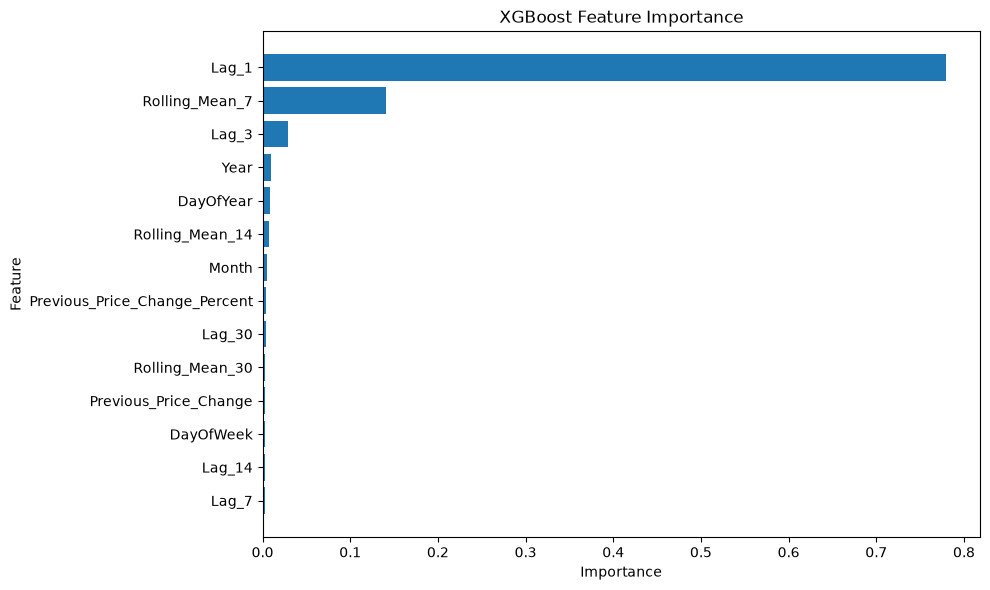

In [156]:
plt.figure(figsize=(10, 6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.gca().invert_yaxis()

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importance")

plt.tight_layout()
plt.show()

In [157]:
# Recreate results dataframe

results = test_data.copy()

results["Actual"] = y_test.values
results["Predicted"] = y_pred

print("Results dataframe created!")
print(results[[
    "Commodity",
    "Price Date",
    "Actual",
    "Predicted"
]].head())

Results dataframe created!
    Commodity Price Date  Actual    Predicted
112     Onion 2025-03-03  2650.0  4020.584229
113     Onion 2025-03-04  2800.0  3420.805176
114     Onion 2025-03-11  2800.0  3161.091553
115     Onion 2025-03-12  2600.0  3069.707275
116     Onion 2025-03-13  2500.0  3052.248535


In [158]:
print(
    results.groupby(
        ["STATE", "District Name", "Market Name", "Commodity"]
    ).size().sort_values(ascending=False).head(10)
)

STATE           District Name  Market Name  Commodity
West Bengal     bankura        Khatra       Potato       161
Andhra Pradesh  warangal       Warangal     Potato       161
Uttar Pradesh   balrampur      Tulsipur     Potato       161
                prayagraj      Ajuha        Potato       161
West Bengal     hooghly        Kalipur      Potato       160
                birbhum        Birbhum      Potato       160
Uttar Pradesh   shahjahanpur   Puwaha       Potato       160
                amethi         Sultanpur    Potato       160
                sambhal        Sambhal      Potato       160
West Bengal     nadia          Nadia        Potato       160
dtype: int64


In [159]:
results["Absolute_Error"] = (
    abs(results["Actual"] - results["Predicted"])
)

results["Error_Percentage"] = (
    results["Absolute_Error"] /
    results["Actual"]
) * 100

print("Mean Absolute Error:",
      results["Absolute_Error"].mean())

print("Mean Error Percentage:",
      results["Error_Percentage"].mean(), "%")

Mean Absolute Error: 162.86115243400323
Mean Error Percentage: 9.739015013404828 %


In [160]:
# Select one market-commodity series
selected = results[
    (results["STATE"] == "West Bengal") &
    (results["District Name"] == "bankura") &
    (results["Market Name"] == "Khatra") &
    (results["Commodity"] == "Potato")
].copy()

# Sort by date
selected = selected.sort_values("Price Date")

print("Selected series records:", len(selected))

print(
    selected[
        [
            "Price Date",
            "Actual",
            "Predicted"
        ]
    ].head(10)
)

Selected series records: 161
       Price Date  Actual    Predicted
573766 2025-01-01  1810.0  1977.523560
573767 2025-01-02  1820.0  1993.572632
573768 2025-01-03  1820.0  1863.919434
573769 2025-01-04  1830.0  1864.386841
573770 2025-01-05  1600.0  1840.851318
573771 2025-01-06  1630.0  1842.105469
573772 2025-01-07  1630.0  1679.677490
573773 2025-01-08  1620.0  1667.887085
573774 2025-01-09  1500.0  1666.004517
573775 2025-01-10  1500.0  1631.780518


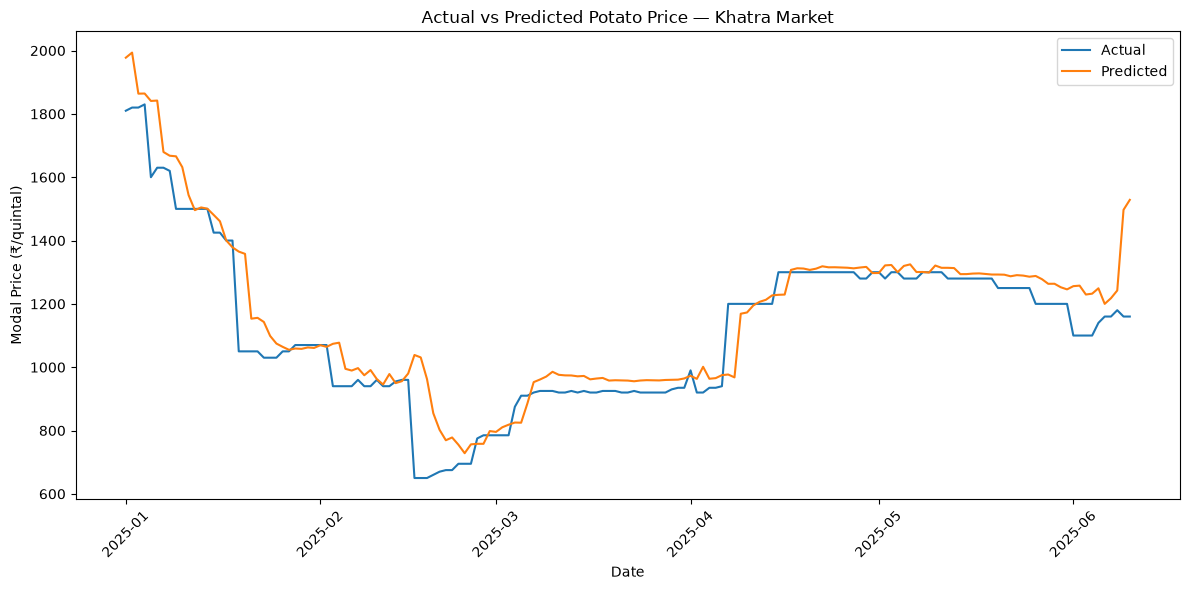

In [161]:
plt.figure(figsize=(12, 6))

plt.plot(
    selected["Price Date"],
    selected["Actual"],
    label="Actual"
)

plt.plot(
    selected["Price Date"],
    selected["Predicted"],
    label="Predicted"
)

plt.xlabel("Date")
plt.ylabel("Modal Price (₹/quintal)")

plt.title(
    "Actual vs Predicted Potato Price — Khatra Market"
)

plt.legend()

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [162]:
market_mae = mean_absolute_error(
    selected["Actual"],
    selected["Predicted"]
)

market_rmse = np.sqrt(
    mean_squared_error(
        selected["Actual"],
        selected["Predicted"]
    )
)

market_r2 = r2_score(
    selected["Actual"],
    selected["Predicted"]
)

print("Khatra Potato Model Performance")
print("=" * 45)
print(f"Records: {len(selected)}")
print(f"MAE  : ₹{market_mae:.2f}")
print(f"RMSE : ₹{market_rmse:.2f}")
print(f"R²   : {market_r2:.4f}")

Khatra Potato Model Performance
Records: 161
MAE  : ₹61.43
RMSE : ₹98.83
R²   : 0.8408


In [163]:
import joblib

joblib.dump(
    model_xgb,
    "agri_price_xgboost_model.pkl"
)

print("✅ XGBoost model saved successfully!")

✅ XGBoost model saved successfully!


In [164]:
joblib.dump(
    feature_columns,
    "feature_columns.pkl"
)

print("✅ Feature list saved successfully!")

✅ Feature list saved successfully!


In [165]:
import os

print("Model exists:", os.path.exists("agri_price_xgboost_model.pkl"))
print("Features exist:", os.path.exists("feature_columns.pkl"))

Model exists: True
Features exist: True


In [166]:
market_daily.to_pickle(
    "market_daily_clean.pkl"
)

print("Market data saved successfully!")
print("Shape:", market_daily.shape)

Market data saved successfully!
Shape: (611718, 23)


In [167]:
import os

print(
    "File exists:",
    os.path.exists("market_daily_clean.pkl")
)

print(
    "File size:",
    round(
        os.path.getsize("market_daily_clean.pkl") / (1024 * 1024),
        2
    ),
    "MB"
)

File exists: True
File size: 118.18 MB
